<a href="https://colab.research.google.com/github/azukaegoo/Floris-Electronic-Health-Record/blob/main/Oasis3_dementia_v2_axis1(Coronal_like_view_73_95percent).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
print(torch.cuda.is_available())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
True


In [ ]:
data_dir = "/content/drive/MyDrive/Colab Notebooks/processed_oasis_v2_axis1"

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os
import pandas as pd

from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:
# =====================================
# DEVICE
# =====================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


#### Slices were extracted corresponding to a coronal-like view after preprocessing.

- Dataset Version: V2, Axis 1
- Normal Subject: 105
- Dementia Subject: 105
- Train-set:        
  - Normal Subject (84)
  - Dementia Subject (84)
- Validation-Set:
  - Normal Subject (21)
  - Dementia Subject (21)



In [ ]:
print(os.listdir("/content/drive/MyDrive/Colab Notebooks/processed_oasis_v2_axis1"))

['val', 'train']


In [ ]:


records = []

for split in ["train", "val"]:
    for label in ["normal", "dementia"]:

        label_path = os.path.join(data_dir, split, label)

        for subject in os.listdir(label_path):

            subject_path = os.path.join(label_path, subject)

            png_count = len([
                f for f in os.listdir(subject_path)
                if f.endswith(".png")
            ])

            records.append({
                "split": split,
                "label": label,
                "subject": subject,
                "num_slices": png_count
            })

slice_count_df = pd.DataFrame(records)
problem_subjects = slice_count_df[slice_count_df["num_slices"] != 100]

print(problem_subjects)

print(slice_count_df.head())

print("\nTotal subjects:", len(slice_count_df))
print("Total slices:", slice_count_df["num_slices"].sum())

     split     label   subject  num_slices
0    train    normal  OAS31161         101
1    train    normal  OAS31145         101
2    train    normal  OAS31113         101
3    train    normal  OAS31090         101
4    train    normal  OAS31136         101
..     ...       ...       ...         ...
205    val  dementia  OAS30394         101
206    val  dementia  OAS30358         101
207    val  dementia  OAS30158         101
208    val  dementia  OAS30388         101
209    val  dementia  OAS30111         101

[210 rows x 4 columns]
   split   label   subject  num_slices
0  train  normal  OAS31161         101
1  train  normal  OAS31145         101
2  train  normal  OAS31113         101
3  train  normal  OAS31090         101
4  train  normal  OAS31136         101

Total subjects: 210
Total slices: 21210


In [ ]:
# =====================================
# MODEL
# =====================================

model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last block
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace classifier
model.fc = nn.Sequential(
    nn.Dropout(0.6),
    nn.Linear(
        model.fc.in_features,
        2
    )
)

model = model.to(device)


In [ ]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

# load pretrained ResNet18 (NEW WAY)
model = resnet18(weights=ResNet18_Weights.DEFAULT)

# replace final layer (VERY IMPORTANT)
model.fc = nn.Linear(model.fc.in_features, 2)

# move to GPU
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# =====================================
# LOSS FUNCTION
# =====================================

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

# =====================================
# OPTIMIZER
# =====================================

optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-5,
    weight_decay=1e-4
)


In [ ]:
# =====================================
# DATA AUGMENTATION
# =====================================

train_transforms = transforms.Compose([
    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.Resize((224, 224)),

    transforms.RandomRotation(20),

    transforms.RandomHorizontalFlip(),

    transforms.RandomAffine(
        degrees=15,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),

    transforms.ToTensor()
])

val_transforms = transforms.Compose([
    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.Resize((224, 224)),

    transforms.ToTensor()
])


/content/drive/MyDrive/Colab Notebooks/processed_oasis_v2_axis1/train/dementia/OAS31067/OAS31067_axis1_slice_140.png


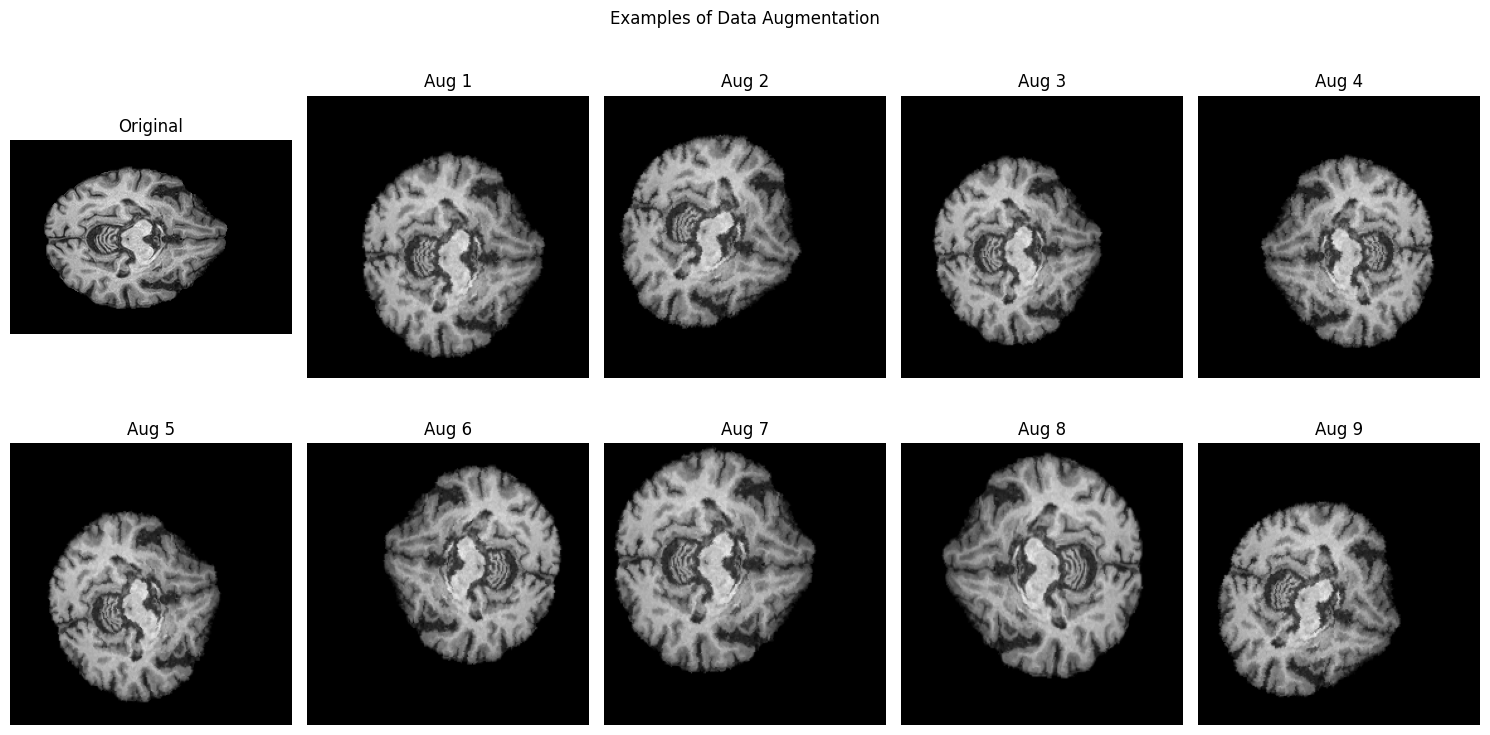

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Pick one subject and one hippocampus-region slice
subject_id = "OAS31067"
slice_number = 140

image_path = os.path.join(
    data_dir,
    "train",
    "dementia",
    subject_id,
    f"{subject_id}_axis1_slice_{slice_number}.png"
)

print(image_path)

img = Image.open(image_path)

plt.figure(figsize=(15, 8))

# Original image
plt.subplot(2, 5, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

# Augmented versions
for i in range(9):
    aug_img = train_transforms(img)
    aug_img = aug_img.permute(1, 2, 0).numpy()

    plt.subplot(2, 5, i + 2)
    plt.imshow(aug_img.squeeze(), cmap="gray")
    plt.title(f"Aug {i+1}")
    plt.axis("off")

plt.suptitle("Examples of Data Augmentation")
plt.tight_layout()

plt.savefig(
    "augmentation_examples_hippocampus_slice.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

1. Minimal data agumentation for the train dataset, testing first with

```
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])
```

2. Stronger data agumentation for the training dataset

```
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),

    transforms.ToTensor()
])
```

In [ ]:
train_dataset = datasets.ImageFolder(
    root=data_dir + "/train",
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=data_dir + "/val",
    transform=val_transforms
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(train_dataset.classes)
print(len(train_dataset), len(val_dataset))

['dementia', 'normal']
16968 4242


In [ ]:
# TRAINING SETTINGS
# =====================================

num_epochs = 30

best_val_acc = 0.0

patience = 5
counter = 0

best_model_path = "/content/drive/MyDrive/Colab Notebooks/best_resnet18_1.pth"

train_loss_history = []
val_loss_history = []

train_acc_history = []
val_acc_history = []


# =====================================
# TRAINING LOOP
# =====================================

for epoch in range(num_epochs):

    # -----------------------
    # TRAIN
    # -----------------------

    model.train()

    running_train_loss = 0.0

    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, preds = torch.max(
            outputs,
            1
        )

        train_correct += (
            preds == labels
        ).sum().item()

        train_total += labels.size(0)

    train_loss = (
        running_train_loss
        / len(train_loader)
    )

    train_acc = (
        100 * train_correct
        / train_total
    )

    # -----------------------
    # VALIDATION
    # -----------------------

    model.eval()

    running_val_loss = 0.0

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_val_loss += loss.item()

            _, preds = torch.max(
                outputs,
                1
            )

            val_correct += (
                preds == labels
            ).sum().item()

            val_total += labels.size(0)

    val_loss = (
        running_val_loss
        / len(val_loader)
    )

    val_acc = (
        100 * val_correct
        / val_total
    )

    # -----------------------
    # SAVE BEST MODEL
    # -----------------------

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            best_model_path
        )

        counter = 0

        print(
            f"Best model saved! "
            f"Val Acc = {val_acc:.2f}%"
        )

    else:

        counter += 1

    # -----------------------
    # EARLY STOPPING
    # -----------------------

    if counter >= patience:

        print(
            "\nEarly stopping triggered!"
        )

        break

    # -----------------------
    # STORE HISTORY
    # -----------------------

    train_loss_history.append(
        train_loss
    )

    val_loss_history.append(
        val_loss
    )

    train_acc_history.append(
        train_acc
    )

    val_acc_history.append(
        val_acc
    )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Train Acc: {train_acc:.2f}% "
        f"Val Acc: {val_acc:.2f}%"
    )

print(
    f"\nBest Validation Accuracy: "
    f"{best_val_acc:.2f}%"
)


Best model saved! Val Acc = 68.67%
Epoch [1/30] Train Loss: 0.6055 Val Loss: 0.6165 Train Acc: 67.96% Val Acc: 68.67%
Best model saved! Val Acc = 69.97%
Epoch [2/30] Train Loss: 0.5427 Val Loss: 0.6010 Train Acc: 75.02% Val Acc: 69.97%
Best model saved! Val Acc = 72.21%
Epoch [3/30] Train Loss: 0.5131 Val Loss: 0.6038 Train Acc: 77.65% Val Acc: 72.21%
Best model saved! Val Acc = 72.28%
Epoch [4/30] Train Loss: 0.4963 Val Loss: 0.5951 Train Acc: 79.29% Val Acc: 72.28%
Best model saved! Val Acc = 73.39%
Epoch [5/30] Train Loss: 0.4783 Val Loss: 0.5864 Train Acc: 80.70% Val Acc: 73.39%
Best model saved! Val Acc = 73.46%
Epoch [6/30] Train Loss: 0.4654 Val Loss: 0.6163 Train Acc: 81.77% Val Acc: 73.46%
Best model saved! Val Acc = 73.55%
Epoch [7/30] Train Loss: 0.4507 Val Loss: 0.6322 Train Acc: 83.00% Val Acc: 73.55%
Best model saved! Val Acc = 73.64%
Epoch [8/30] Train Loss: 0.4434 Val Loss: 0.6337 Train Acc: 83.40% Val Acc: 73.64%
Best model saved! Val Acc = 73.88%
Epoch [9/30] Train Lo

In [ ]:
# =====================================
# LOAD BEST MODEL
# =====================================

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

# =====================================
# EVALUATION
# =====================================

model.eval()

all_preds = []
all_labels = []

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(
            outputs,
            1
        )

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

accuracy = (
    100 * correct
    / total
)

print(
    f"\nValidation Accuracy: "
    f"{accuracy:.2f}%"
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        all_labels,
        all_preds
    )
)

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=val_dataset.classes
    )
)



Validation Accuracy: 73.95%

Confusion Matrix:
[[1500  621]
 [ 484 1637]]

Classification Report:
              precision    recall  f1-score   support

    dementia       0.76      0.71      0.73      2121
      normal       0.72      0.77      0.75      2121

    accuracy                           0.74      4242
   macro avg       0.74      0.74      0.74      4242
weighted avg       0.74      0.74      0.74      4242



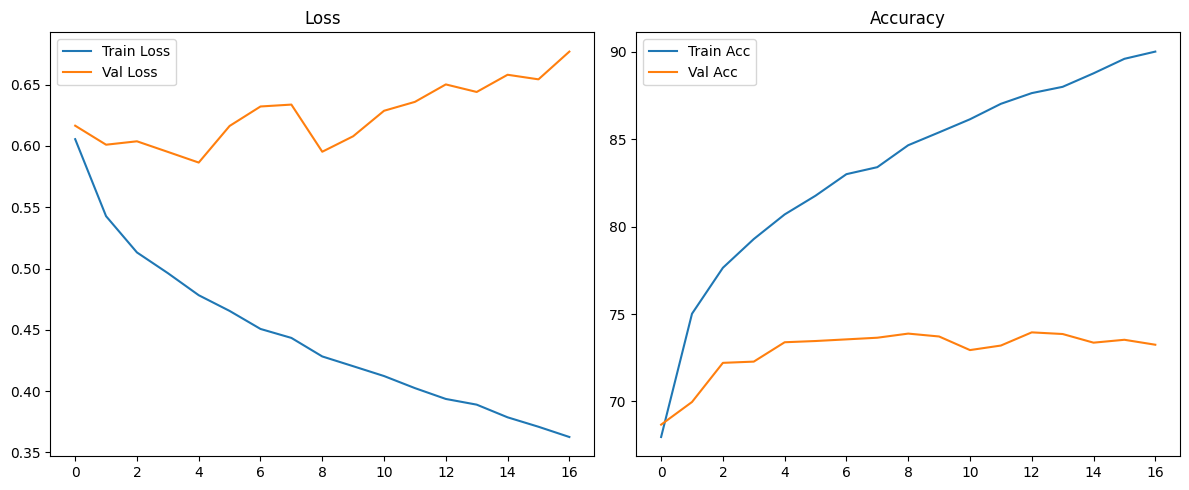

In [ ]:
# =====================================
# PLOTS
# =====================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(
    train_loss_history,
    label="Train Loss"
)
plt.plot(
    val_loss_history,
    label="Val Loss"
)
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(
    train_acc_history,
    label="Train Acc"
)
plt.plot(
    val_acc_history,
    label="Val Acc"
)
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()
